# ML Ensemble Models for IoT IDS

## Models Implemented:
1. **Random Forest** - Bagging ensemble
2. **XGBoost** - Gradient boosting ensemble

## Evaluation Metrics:
- Accuracy, Precision, Recall, F1-Score
- ROC-AUC, PR-AUC
- Confusion Matrix
- Classification Report

In [ ]:
import os
import time
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.calibration import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                            roc_auc_score, average_precision_score, confusion_matrix,
                            classification_report, roc_curve, precision_recall_curve)
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV

In [3]:
np.random.seed(42)
RANDOM_STATE = 42

## 1. Data Loading and Preprocessing

Load the preprocessed data from the data preprocessing notebook.


In [5]:
# Load the preprocessed data
def load_preprocessed_data():
    try:
        X_train = pd.read_csv('data/preprocessedTrain.csv')
        X_test = pd.read_csv('data/preprocessedTest.csv')        
        
        # Separate features and target
        y_train = X_train.pop('Attack_type')
        le = LabelEncoder().fit(y_train)
        y_train = le.transform(y_train)

        y_test = X_test.pop('Attack_type')
        y_test = le.transform(y_test)
        print(le.classes_)

        print("Preprocessed data loaded successfully!")
        print(f"Train data shape: {X_train.shape}")
        print(f"Test data shape: {X_test.shape}")
        
        return X_train, X_test, y_train, y_test
        
    except FileNotFoundError as e:
        print(f"Error loading preprocessed data: {e}")
        print("Please make sure you have run the CSI4999_dataPreprocessing.ipynb notebook first.")
        print("Expected files: data/preprocessedTrain.csv and data/preprocessedTest.csv")
        return None, None, None, None
    
X_train, X_test, y_train, y_test = load_preprocessed_data()

['ARP_poisioning' 'DDOS_Slowloris' 'DOS_SYN_Hping' 'MQTT_Publish'
 'Metasploit_Brute_Force_SSH' 'NMAP_FIN_SCAN' 'NMAP_OS_DETECTION'
 'NMAP_TCP_scan' 'NMAP_UDP_SCAN' 'NMAP_XMAS_TREE_SCAN' 'Thing_Speak'
 'Wipro_bulb']
Preprocessed data loaded successfully!
Train data shape: (98493, 82)
Test data shape: (24624, 82)


### Split train-val

In [6]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

## 2. Model Definition and Configuration

Define all the ensemble models with base hyperparameter configurations.

In [19]:
def get_model_configs():
    models = {}
    
    models['RandomForest'] = {
        'model': RandomForestClassifier(
            class_weight='balanced',
            random_state=RANDOM_STATE,
            n_jobs=-1
        ),
        'param_grid': {
            'n_estimators': [50, 100, 200],
            'max_depth': [10, 15, None],
            'min_samples_leaf': [1, 2],
        }
    }
        
    models['XGBoost'] = {
        'model': XGBClassifier(
            random_state= RANDOM_STATE,
            n_jobs= -1,
            objective= 'multi:softprob', # can do 'multi:softmax' as well
        ),
        'param_grid': {
            'n_estimators': [50, 100, 200],
            'max_depth': [3, 5, 6],
            'learning_rate': [0.01, 0.1, 0.3],
            'min_child_weight':[1,5,10],
            'colsample_bytree': [.6,.8,1],
        }
    }
    return models

# Get model configurations
model_configs = get_model_configs()

## 3. Model Training and Hyperparameter Tuning

#### Baseline models


In [9]:
rf_base = RandomForestClassifier(random_state=RANDOM_STATE,
                            verbose=1,
                            class_weight='balanced',).fit(X_train,y_train)

print(classification_report(y_train, rf_base.predict(X_train)))
print("Validation\n",classification_report(y_val,rf_base.predict(X_val),digits=4))

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    4.5s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    9.7s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.4s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    1.0s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s


              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4960
           1       1.00      1.00      1.00       342
           2       1.00      1.00      1.00     60581
           3       1.00      1.00      1.00      2653
           4       0.96      1.00      0.98        24
           5       1.00      1.00      1.00        18
           6       1.00      1.00      1.00      1280
           7       1.00      1.00      1.00       642
           8       1.00      1.00      1.00      1657
           9       1.00      1.00      1.00      1286
          10       1.00      1.00      1.00      5189
          11       1.00      1.00      1.00       162

    accuracy                           1.00     78794
   macro avg       1.00      1.00      1.00     78794
weighted avg       1.00      1.00      1.00     78794

Validation
               precision    recall  f1-score   support

           0     0.9848    0.9903    0.9875      1240
           1

[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.1s finished


In [10]:
xgb_base = XGBClassifier(booster='gbtree',
                    random_state= RANDOM_STATE,
                    n_jobs= -1,
                    objective= 'multi:softprob', # can do 'multi:softmax' as well
                    verbosity=2,
                    ).fit(X_train,y_train)
print(classification_report(y_train, xgb_base.predict(X_train)))
print("Validation\n",classification_report(y_val, xgb_base.predict(X_val),digits=4))

[23:21:25] INFO: D:\bld\xgboost-split_1758007502304\work\src\data\iterative_dmatrix.cc:53: Finished constructing the `IterativeDMatrix`: (78794, 82, 6389154).
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4960
           1       1.00      1.00      1.00       342
           2       1.00      1.00      1.00     60581
           3       1.00      1.00      1.00      2653
           4       1.00      0.96      0.98        24
           5       1.00      1.00      1.00        18
           6       1.00      1.00      1.00      1280
           7       1.00      1.00      1.00       642
           8       1.00      1.00      1.00      1657
           9       1.00      1.00      1.00      1286
          10       1.00      1.00      1.00      5189
          11       1.00      1.00      1.00       162

    accuracy                           1.00     78794
   macro avg       1.00      1.00      1.00     78794
weighted avg       1.00      

#### Hyperparameter Tuning

In [12]:
def tune_model(model, param_grid, X_train, y_train, model_name, use_random_search=True):
    print(f"\n{'='*50}")
    print(f"Training {model_name}")
    print(f"{'='*50}")

    # Hyperparameter tuning
    if use_random_search:
        search = RandomizedSearchCV(
            model, param_grid, n_iter=20, cv=5, scoring='f1_macro',
            random_state=RANDOM_STATE, n_jobs=-1, verbose=2
        )
    else:
        search = GridSearchCV(
            model, param_grid, cv=5, scoring='f1_macro',
            n_jobs=-1, verbose=2
        )
    
    search.fit(X_train, y_train)
    best_model = search.best_estimator_
    print(f"Best parameters: {search.best_params_}")
    print(f"Best CV score: {search.best_score_:.4f}")

    return best_model

In [13]:
tune_model(model_configs['XGBoost']['model'],model_configs['XGBoost']['param_grid'],X_train,y_train,'xgb')


Training xgb
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters: {'n_estimators': 100, 'min_child_weight': 1, 'max_depth': 6, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
Best CV score: 0.9713


,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [16]:
rf_base

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [20]:
tune_model(model_configs['RandomForest']['model'],model_configs['RandomForest']['param_grid'],X_train,y_train,'RF',use_random_search=False)


Training RF
Fitting 5 folds for each of 18 candidates, totalling 90 fits


c:\Users\willo_jlqcl0r\miniconda3\envs\caps\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 18 is smaller than n_iter=20. Running 18 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best parameters: {'n_estimators': 100, 'min_samples_leaf': 1, 'max_depth': 15}
Best CV score: 0.9650


,n_estimators,100
,criterion,'gini'
,max_depth,15
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


    
#### Add timing metrics here... do it of an average of fitting it several times for more accurate results
```python
# metrics['training_time'] = training_time

# print(f"Training time: {training_time:.2f} seconds")
# all_metrics.append(metrics)
```

In [22]:
bestXGB = XGBClassifier(booster='gbtree',
                    n_estimators=200,
                    objective='binary:logistic',
                    seed=RANDOM_STATE,
                    verbosity=0,
                    scale_pos_weight= (len(y_train) - y_train.sum()) / y_train.sum(), 
                    ).fit(X_train,y_train)

In [23]:
bestRF = RandomForestClassifier(random_state=RANDOM_STATE,
                            n_estimators= 100,
                            min_samples_leaf= 1,
                            max_depth=15,
                            verbose=0,
                            class_weight='balanced',).fit(X_train,y_train)

## 4. Calculate Metrics

In [21]:
def calculate_metrics(model, y_true, model_name):
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test) if hasattr(model, 'predict_proba') else None
    
    metrics = {
        'model_name': model_name,
        'accuracy': accuracy_score(y_true, y_pred),
        'precision_macro': precision_score(y_true, y_pred, average='macro'),
        'recall_macro': recall_score(y_true, y_pred, average='macro'),
        'f1_macro': f1_score(y_true, y_pred, average='macro'),
        'precision_weighted': precision_score(y_true, y_pred, average='weighted'),
        'recall_weighted': recall_score(y_true, y_pred, average='weighted'),
        'f1_weighted': f1_score(y_true, y_pred, average='weighted')
    }
    
    # ROC-AUC and PR-AUC (for multiclass)
    if y_pred_proba is not None:
        try:
            metrics['roc_auc_ovr'] = roc_auc_score(y_true, y_pred_proba, multi_class='ovr', average='macro')
            metrics['roc_auc_ovo'] = roc_auc_score(y_true, y_pred_proba, multi_class='ovo', average='macro')
            metrics['pr_auc'] = average_precision_score(y_true, y_pred_proba, average='macro')
        except:
            metrics['roc_auc_ovr'] = None
            metrics['roc_auc_ovo'] = None
            metrics['pr_auc'] = None
    
    return metrics
all_metrics=[]

In [24]:
xgb_metrics = calculate_metrics(bestXGB,y_test,'xgb')
all_metrics.append(xgb_metrics)
xgb_metrics

{'model_name': 'xgb',
 'accuracy': 0.9980100714749838,
 'precision_macro': 0.9959744057603245,
 'recall_macro': 0.960832963872003,
 'f1_macro': 0.9771503440422323,
 'precision_weighted': 0.9980156565222292,
 'recall_weighted': 0.9980100714749838,
 'f1_weighted': 0.9980038991305056,
 'roc_auc_ovr': 0.9999773629140126,
 'roc_auc_ovo': np.float64(0.99977691987219),
 'pr_auc': 0.9840533661795826}

In [27]:
rf_metrics = calculate_metrics(bestRF,y_test,'rf')
all_metrics.append(rf_metrics)
rf_metrics

{'model_name': 'rf',
 'accuracy': 0.9982131254061078,
 'precision_macro': 0.9608683096727325,
 'recall_macro': 0.9658194452878411,
 'f1_macro': 0.9630212468746929,
 'precision_weighted': 0.998225096762651,
 'recall_weighted': 0.9982131254061078,
 'f1_weighted': 0.998216756690694,
 'roc_auc_ovr': 0.993497163520021,
 'roc_auc_ovo': np.float64(0.9932717244546794),
 'pr_auc': 0.9758126404085655}

## 5. Model Performance Comparison

Compare the performance of all trained models.


In [28]:
# Create performance comparison DataFrame
results_df = pd.DataFrame(all_metrics)
results_df = results_df.set_index('model_name')

# Display results
print("\nModel Performance Comparison:")
print("="*80)

# Sort by F1-macro score
results_sorted = results_df.sort_values('f1_macro', ascending=False)

# Display key metrics
key_metrics = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']
print(results_sorted[key_metrics].round(4))

# Display ROC-AUC if available
if 'roc_auc_ovr' in results_df.columns:
    print("\nROC-AUC Scores:")
    roc_metrics = ['roc_auc_ovr', 'roc_auc_ovo', 'pr_auc']
    available_roc_metrics = [col for col in roc_metrics if col in results_df.columns]
    print(results_sorted[available_roc_metrics].round(4))


Model Performance Comparison:
            accuracy  precision_macro  recall_macro  f1_macro
model_name                                                   
xgb           0.9980           0.9960        0.9608    0.9772
rf            0.9982           0.9609        0.9658    0.9630
rf            0.9982           0.9609        0.9658    0.9630
rf            0.9982           0.9609        0.9658    0.9630

ROC-AUC Scores:
            roc_auc_ovr  roc_auc_ovo  pr_auc
model_name                                  
xgb              1.0000       0.9998  0.9841
rf               0.9935       0.9933  0.9758
rf               0.9865       0.9863  0.9726
rf               0.9935       0.9933  0.9758


## 6. Detailed Model Analysis

Analyze the best performing models in detail.


Best performing model: xgb
F1-Score (Macro): 0.9772
Accuracy: 0.9980


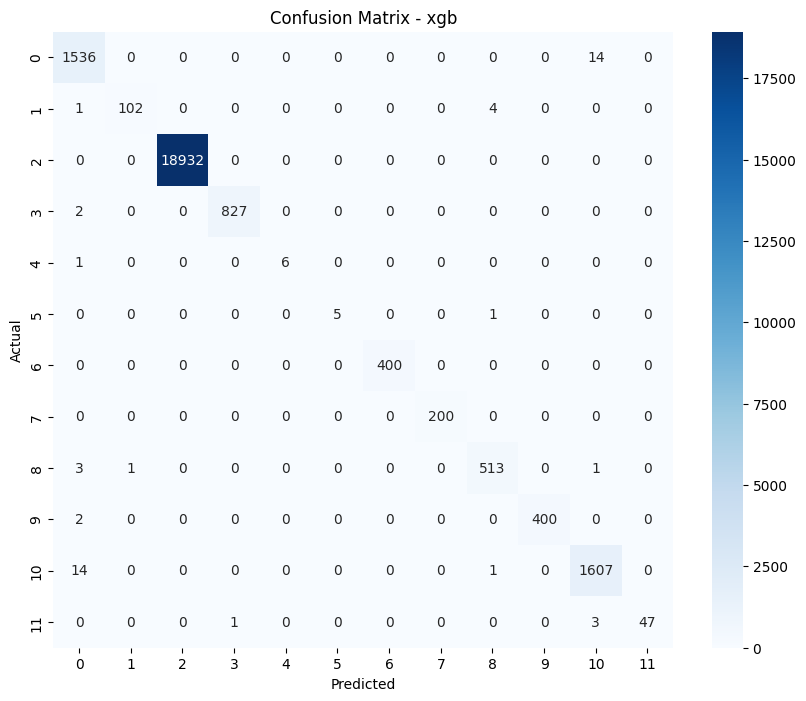

In [30]:
# Get the best model
trained_models={}
trained_models['xgb']=bestXGB
trained_models['rf']=bestRF
best_model_name = results_sorted.index[0]
best_model = trained_models[best_model_name]

print(f"Best performing model: {best_model_name}")
print(f"F1-Score (Macro): {results_sorted.loc[best_model_name, 'f1_macro']:.4f}")
print(f"Accuracy: {results_sorted.loc[best_model_name, 'accuracy']:.4f}")

# Make predictions with best model
y_pred_best = best_model.predict(X_test)
y_pred_proba_best = best_model.predict_proba(X_test) if hasattr(best_model, 'predict_proba') else None

# Confusion Matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=range(len(np.unique(y_test))),
            yticklabels=range(len(np.unique(y_test))))
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## 7. Model Saving and Inference Functions

Save the trained models and create inference functions.


In [31]:
# Create models directory if it doesn't exist
os.makedirs('models', exist_ok=True)

def save_models(trained_models, results_df):
    # Save all trained models
    for model_name, model in trained_models.items():
        model_path = f'models/{model_name.lower()}_multi_model.pkl'
        joblib.dump(model, model_path)
        print(f"Saved {model_name} to {model_path}")
    
    # Save results
    results_df.to_csv('models/ml_multi_performance_results.csv')
    print("Saved model performance results to models/ml_multi_performance_results.csv")
    
    # Save best model separately
    best_model_name = results_df.index[0]
    best_model = trained_models[best_model_name]
    joblib.dump(best_model, 'models/best_multi_ml.pkl')
    print(f"Saved best model ({best_model_name}) to models/best_multi_ml.pkl")

save_models(trained_models, results_sorted)

Saved xgb to models/xgb_multi_model.pkl
Saved rf to models/rf_multi_model.pkl
Saved model performance results to models/ml_multi_performance_results.csv
Saved best model (xgb) to models/best_multi_ml.pkl
